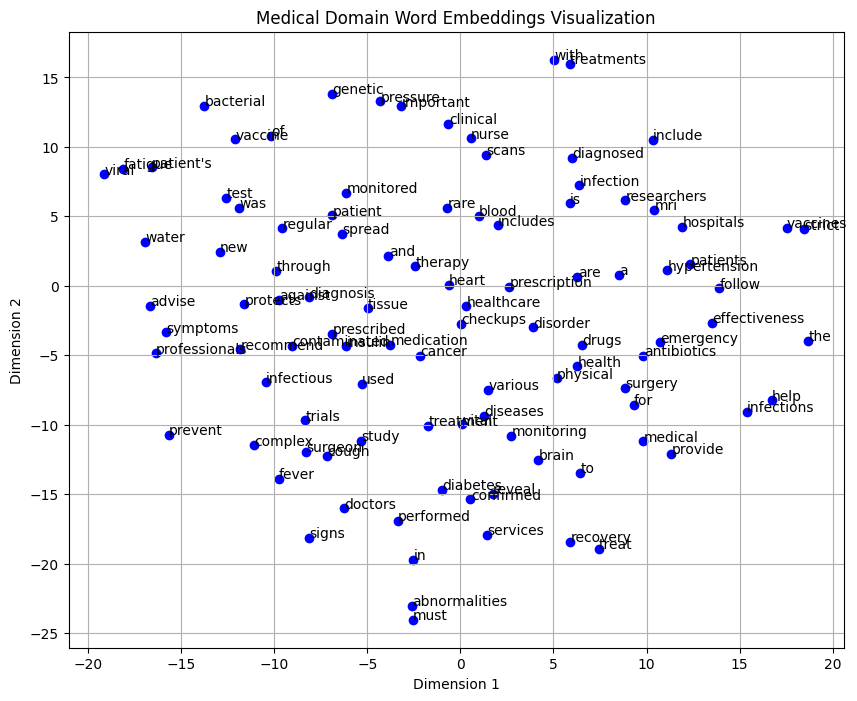


Words similar to 'treatment':
vital (0.35)
effectiveness (0.34)
the (0.29)
and (0.28)
follow (0.25)

Words similar to 'vaccine':
abnormalities (0.34)
genetic (0.31)
reveal (0.27)
was (0.25)
confirmed (0.24)

Words similar to 'patient':
genetic (0.31)
spread (0.29)
through (0.27)
and (0.27)
pressure (0.25)


In [1]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
from gensim.models import Word2Vec

# Expanded medical corpus
medical_corpus = [
    "The patient was diagnosed with diabetes and hypertension",
    "Doctors prescribed insulin therapy for diabetes treatment",
    "MRI scans reveal abnormalities in the brain tissue",
    "The treatment includes antibiotics and medication",
    "Symptoms include fever cough and fatigue",
    "The vaccine protects against viral infections",
    "Doctors recommend physical therapy for recovery",
    "The surgeon performed a complex heart surgery",
    "Patients must follow a strict medical prescription",
    "The diagnosis confirmed a rare genetic disorder",
    "Medical researchers study new cancer treatments",
    "Hospitals provide emergency healthcare services",
    "Blood pressure monitoring is important for patients",
    "Vaccines help prevent infectious diseases",
    "The nurse monitored the patient's vital signs",
    "Clinical trials test the effectiveness of drugs",
    "Healthcare professionals treat various diseases",
    "The infection spread through contaminated water",
    "Doctors advise regular health checkups",
    "Antibiotics are used to treat bacterial infections"
]

# Preprocess corpus
processed_corpus = [sentence.lower().split() for sentence in medical_corpus]

# Train Word2Vec model
model = Word2Vec(
    sentences=processed_corpus,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    epochs=100
)

# Extract embeddings
words = list(model.wv.index_to_key)
embeddings = np.array([model.wv[word] for word in words])

# Reduce dimensions using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
tsne_result = tsne.fit_transform(embeddings)

# Plot embeddings
plt.figure(figsize=(10,8))
plt.scatter(tsne_result[:,0], tsne_result[:,1], color='blue')

for i, word in enumerate(words):
    plt.text(tsne_result[i,0]+0.02, tsne_result[i,1]+0.02, word)

plt.title("Medical Domain Word Embeddings Visualization")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()

# Function to find similar words
def find_similar_words(input_word, top_n=5):
    try:
        similar_words = model.wv.most_similar(input_word, topn=top_n)
        print(f"\nWords similar to '{input_word}':")
        for word, similarity in similar_words:
            print(f"{word} ({similarity:.2f})")
    except KeyError:
        print(f"'{input_word}' not found in vocabulary.")

# Test semantic similarity
find_similar_words("treatment")
find_similar_words("vaccine")
find_similar_words("patient")